<a href="https://colab.research.google.com/github/MARCOBRAYANGONZALEZGONZALEZ/EDP-I-EJERCICIOS-/blob/main/Codigos_17_mayo_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression

# Configuración simple
symbol = "^GSPC"
lookback_days = 30

# Obtener datos
end_date = datetime.now()
start_date = end_date - timedelta(days=lookback_days * 2)
ticker = yf.Ticker(symbol)
data = ticker.history(start=start_date, end=end_date)

# Preparar datos
data['returns'] = data['Close'].pct_change()
data['ma_5'] = data['Close'].rolling(window=5).mean()
data['ma_10'] = data['Close'].rolling(window=10).mean()
data = data.dropna()

# Entrenar modelo
X = data[['returns', 'ma_5']].values
y = data['Close'].values
model = LinearRegression()
model.fit(X[:-1], y[1:])  # Predecir siguiente día

# Predecir
last_features = X[-1].reshape(1, -1)
next_price = model.predict(last_features)[0]

print(f"💰 Precio actual S&P 500: ${data['Close'].iloc[-1]:.2f}")
print(f"🔮 Predicción próximo día: ${next_price:.2f}")
print(f"📈 Cambio esperado: {((next_price - data['Close'].iloc[-1])/data['Close'].iloc[-1])*100:.2f}%")

💰 Precio actual S&P 500: $7412.80
🔮 Predicción próximo día: $7427.61
📈 Cambio esperado: 0.20%


[*********************100%***********************]  1 of 1 completed

Precio inicial (15-May-2026): 7416.33
Media diaria: 0.000449
Volatilidad diaria: 0.011241



========== PRONÓSTICO ==========
Fecha objetivo: 2026-06-19
Precio esperado: 7497.11
Mediana: 7485.83
Percentil 5%: 6824.03
Percentil 95%: 8212.20


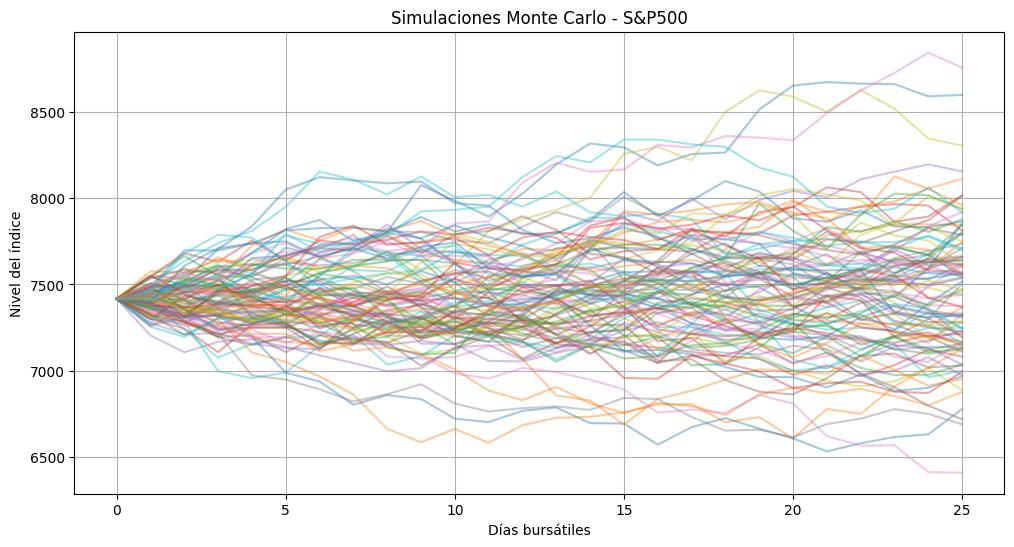

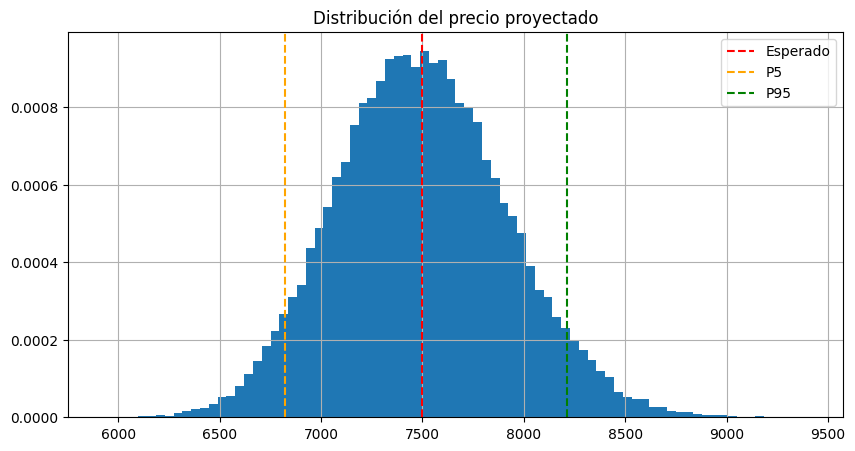

In [90]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime

# ============================================
# CONFIGURACIÓN
# ============================================

ticker = "^GSPC"

# Último dato permitido
fecha_final_datos = "2026-05-15"

# Fecha objetivo
fecha_objetivo = "2026-06-19"

# Número de simulaciones
n_simulaciones = 50000

# Días bursátiles aproximados entre fechas
dias_proyeccion = 25

# ============================================
# DESCARGA DE DATOS
# ============================================

datos = yf.download(
    ticker,
    start="2015-01-01",
    end="2026-05-16",  # incluye cierre del 15 de mayo
    auto_adjust=True
)

cierres = datos["Close"]

# ============================================
# RENDIMIENTOS LOGARÍTMICOS
# ============================================

retornos = np.log(cierres / cierres.shift(1)).dropna()

# Parámetros estadísticos
mu = retornos.mean()
sigma = retornos.std()

# Precio actual
S0 = cierres.iloc[-1]

print(f"Precio inicial (15-May-2026): {S0.item():.2f}")
print(f"Media diaria: {mu.item():.6f}")
print(f"Volatilidad diaria: {sigma.item():.6f}")

# ============================================
# SIMULACIÓN MONTE CARLO (GBM)
# ============================================

np.random.seed(42)

# Matriz de shocks aleatorios
Z = np.random.normal(size=(dias_proyeccion, n_simulaciones))

# Trayectorias
trayectorias = np.zeros((dias_proyeccion + 1, n_simulaciones))
trayectorias[0] = S0.item()

for t in range(1, dias_proyeccion + 1):
    trayectorias[t] = trayectorias[t-1] * np.exp(
        (mu.item() - 0.5 * sigma.item()**2) + sigma.item() * Z[t-1]
    )

# Precio final simulado
precios_finales = trayectorias[-1]

# ============================================
# RESULTADOS
# ============================================

precio_esperado = precios_finales.mean()
mediana = np.median(precios_finales)

p5 = np.percentile(precios_finales, 5)
p95 = np.percentile(precios_finales, 95)

print("\n========== PRONÓSTICO ==========")
print(f"Fecha objetivo: {fecha_objetivo}")
print(f"Precio esperado: {precio_esperado:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Percentil 5%: {p5:.2f}")
print(f"Percentil 95%: {p95:.2f}")

# ============================================
# GRÁFICAS
# ============================================

# Algunas trayectorias
plt.figure(figsize=(12,6))
plt.plot(trayectorias[:, :100], alpha=0.4)
plt.title("Simulaciones Monte Carlo - S&P500")
plt.xlabel("Días bursátiles")
plt.ylabel("Nivel del índice")
plt.grid(True)
plt.show()

# Distribución final
plt.figure(figsize=(10,5))
plt.hist(precios_finales, bins=80, density=True)
plt.axvline(precio_esperado, color='red', linestyle='--', label='Esperado')
plt.axvline(p5, color='orange', linestyle='--', label='P5')
plt.axvline(p95, color='green', linestyle='--', label='P95')
plt.title("Distribución del precio proyectado")
plt.legend()
plt.grid(True)
plt.show()

--- Predicción S&P 500 al 19 de Junio 2026 ---
Precio promedio esperado: 7493.48
Rango de confianza 90%: [6894.37 - 8117.54]


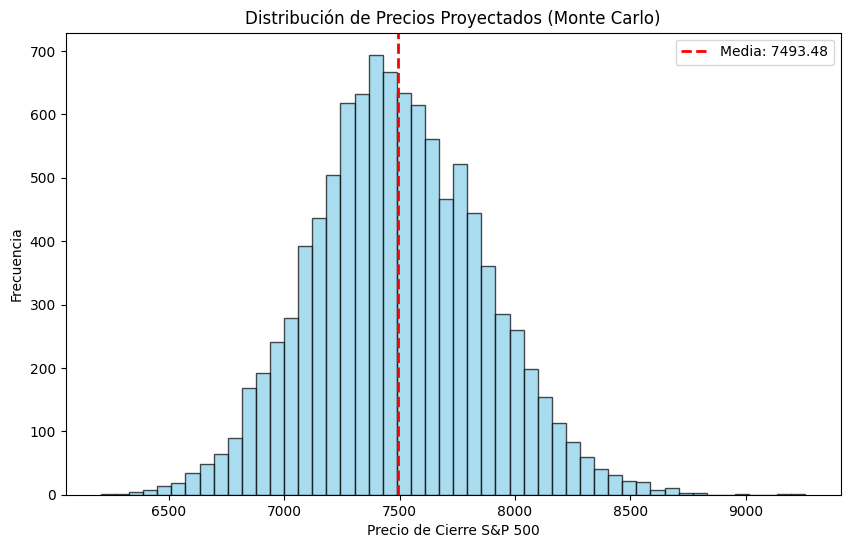

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configuración de parámetros (Datos al 15 de mayo de 2026)
S0 = 7425.00          # Precio de cierre estimado al 15 de mayo
mu = 0.10             # Rendimiento anual esperado (10%)
sigma = 0.16          # Volatilidad anualizada (16%)
dias_habiles = 24     # Días de trading entre el 15 mayo y 19 junio
T = dias_habiles/252  # Tiempo expresado en fracción de año
n_simulaciones = 10000

# 2. Simulación de Monte Carlo
# Generamos rendimientos aleatorios basados en una distribución normal
# Fórmula: St = S0 * exp((mu - 0.5*sigma^2)*T + sigma*sqrt(T)*Z)
Z = np.random.standard_normal(n_simulaciones)
precios_finales = S0 * np.exp((mu - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

# 3. Análisis de Resultados
media = np.mean(precios_finales)
percentil_5 = np.percentile(precios_finales, 5)
percentil_95 = np.percentile(precios_finales, 95)

print(f"--- Predicción S&P 500 al 19 de Junio 2026 ---")
print(f"Precio promedio esperado: {media:.2f}")
print(f"Rango de confianza 90%: [{percentil_5:.2f} - {percentil_95:.2f}]")

# 4. Visualización de la distribución
plt.figure(figsize=(10, 6))
plt.hist(precios_finales, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media:.2f}')
plt.title('Distribución de Precios Proyectados (Monte Carlo)')
plt.xlabel('Precio de Cierre S&P 500')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()